# Latent Class Analysis (LCA)

## Purpose

This notebook uses Latent Class Analysis (LCA) to profile borrower risk in a 25,000-loan sample drawn from the Lending Club dataset. LCA is a model-based clustering technique that identifies unobserved (latent) subgroups within categorical data based on shared patterns across multiple indicators — interest rate, annual income, debt-to-income ratio, FICO score, and loan purpose.

Unlike a single risk score or pre-defined segmentation, LCA lets the data reveal natural groupings of borrowers and assigns each one a probability of membership in each class. The result is a richer, probabilistic segmentation that can support credit decisioning, pricing, and portfolio monitoring.

**Goals of the analysis:**
- Determine the number of distinct risk classes supported by the data
- Characterize each class by its defining features and default behavior


In [20]:
import warnings
warnings.filterwarnings('ignore')


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer
from sklearn.mixture import GaussianMixture

print("✅ Kernel restarted and script running...")

✅ Kernel restarted and script running...


In [22]:
# Define Paths
DATA_PATH = "lendingclub_sample_25000.csv"   # input file
OUTPUT_DIR = "."                             # change to wherever you want outputs

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

In [23]:
# Customer ID for traceability
if 'id' in df_raw.columns:
    df_raw['customer_id'] = df_raw['id']
elif 'member_id' in df_raw.columns:
    df_raw['customer_id'] = df_raw['member_id']
else:
    df_raw['customer_id'] = df_raw.index

# Select and clean relevant columns
cols = ['customer_id', 'int_rate', 'annual_inc', 'dti',
        'fico_range_high', 'purpose', 'loan_status']
df = df_raw[cols].dropna()

# Simplify purpose into 4 groups
purpose_mapping = {
    'debt_consolidation': 'Debt',
    'credit_card':        'Debt',
    'home_improvement':   'Investment',
    'major_purchase':     'Investment',
    'small_business':     'Investment',
    'car':                'Personal',
    'vacation':           'Personal',
    'wedding':            'Personal',
    'moving':             'Personal',
    'medical':            'Personal',
    'other':              'Other',
    'house':              'Other',
    'renewable_energy':   'Other',
    'educational':        'Other'
}
df['purpose'] = df['purpose'].map(purpose_mapping)
df = df[df['purpose'].notna()]   # drop any unmapped purposes

# Consolidate loan_status into 3 groups
status_map = {
    'Fully Paid':           'Good',
    'Current':              'Good',
    'Charged Off':          'Bad',
    'Default':              'Bad',
    'Late (16-30 days)':    'Bad',
    'Late (31-120 days)':   'Bad',
    'In Grace Period':      'Neutral',
    'Issued':               'Neutral'
}
df['loan_status'] = df['loan_status'].map(status_map)
df = df[df['loan_status'].notna()]

# Encode purpose and loan_status (alphabetical order!)
#   purpose      : Debt=0, Investment=1, Other=2, Personal=3
#   loan_status  : Bad=0,  Good=1,       Neutral=2
df['purpose']     = LabelEncoder().fit_transform(df['purpose'])
df['loan_status'] = LabelEncoder().fit_transform(df['loan_status'])

# Discretize continuous features into 3 quantile bins
#   bin 0 = Low, bin 1 = Medium, bin 2 = High
continuous_cols = ['int_rate', 'annual_inc', 'dti', 'fico_range_high']
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
df[continuous_cols] = discretizer.fit_transform(df[continuous_cols])

print(f"Final dataset: {len(df):,} rows")

Final dataset: 24,957 rows


In [24]:
# Features for clustering (drop outcome and ID)
X = df.drop(columns=['loan_status', 'customer_id'])

# Fit GMM for 4 latent classes
gmm = GaussianMixture(n_components=4, random_state=42)
raw_classes = gmm.fit_predict(X)

# ---- Stabilize class numbering: largest segment becomes Class 0 ----
order = pd.Series(raw_classes).value_counts().index.tolist()  # most -> least common
remap = {old: new for new, old in enumerate(order)}
df['latent_class'] = pd.Series(raw_classes, index=df.index).map(remap)

print("Class sizes (after re-numbering):")
print(df['latent_class'].value_counts().sort_index())

# After viewing the heatmap, label each class based on its profile.
# Example below — adjust to match what your run produces.
risk_labels = {
    0: "Class 0",
    1: "Class 1",
    2: "Class 2",
    3: "Class 3"
}
df['risk_label'] = df['latent_class'].map(risk_labels)

# Export full dataset and per-class files
df.to_csv(f"{OUTPUT_DIR}/lendingclub_with_latent_classes.csv", index=False)
for class_id in sorted(df['latent_class'].unique()):
    class_df = df[df['latent_class'] == class_id]
    class_df.to_csv(f"{OUTPUT_DIR}/latent_class_{class_id}_customers.csv", index=False)
    class_df.describe(include='all').to_csv(
        f"{OUTPUT_DIR}/latent_class_{class_id}_summary.csv")



Class sizes (after re-numbering):
latent_class
0    8333
1    7005
2    5190
3    4429
Name: count, dtype: int64


In [25]:
# ---- Build the within-class proportion table ----
# IMPORTANT: drop both customer_id AND risk_label before the groupby,
# otherwise risk_label leaks into the summary.
summary = (
    df.drop(columns=['customer_id', 'risk_label'])
      .groupby('latent_class')
      .agg(lambda x: x.value_counts(normalize=True).to_dict())
)

expanded_summary = {}
for col in summary.columns:
    temp_df = pd.DataFrame(summary[col].tolist(), index=summary.index)
    temp_df.columns = [f"{col}_{str(c)}" for c in temp_df.columns]
    expanded_summary.update(temp_df.to_dict(orient="series"))
summary_df = pd.DataFrame(expanded_summary)

# Column percent (within-class) table
col_percent = (summary_df * 100).round(1)
col_percent.to_csv(f"{OUTPUT_DIR}/latent_class_summary_4class_column_percents.csv")

# ---- CORRECTED label map ----
# Continuous (KBinsDiscretizer quantile): 0=Low, 1=Medium, 2=High
# purpose (LabelEncoder, alphabetical):    0=Debt, 1=Investment, 2=Other, 3=Personal
# loan_status (LabelEncoder, alphabetical):0=Bad,  1=Good,       2=Neutral
label_map = {
    'int_rate_0.0':        'Low Interest Rate',
    'int_rate_1.0':        'Medium Interest Rate',
    'int_rate_2.0':        'High Interest Rate',
    'annual_inc_0.0':      'Low Income',
    'annual_inc_1.0':      'Medium Income',
    'annual_inc_2.0':      'High Income',
    'dti_0.0':             'Low DTI',
    'dti_1.0':             'Medium DTI',
    'dti_2.0':             'High DTI',
    'fico_range_high_0.0': 'Low FICO',
    'fico_range_high_1.0': 'Medium FICO',
    'fico_range_high_2.0': 'High FICO',
    'purpose_0':           'Debt Consolidation',
    'purpose_1':           'Investment',
    'purpose_2':           'Other',
    'purpose_3':           'Personal',
    'loan_status_0':       'Bad Loan',
    'loan_status_1':       'Good Loan',
    'loan_status_2':       'Neutral'
}

# Optional: order rows the way you want them displayed
row_order = [
    'Low Interest Rate', 'Medium Interest Rate', 'High Interest Rate',
    'Low Income', 'Medium Income', 'High Income',
    'Low DTI', 'Medium DTI', 'High DTI',
    'Low FICO', 'Medium FICO', 'High FICO',
    'Debt Consolidation', 'Investment', 'Personal', 'Other',
    'Good Loan', 'Neutral', 'Bad Loan'
]

col_percent_labeled = col_percent.T.copy()
col_percent_labeled.index = [label_map.get(lbl, lbl) for lbl in col_percent_labeled.index]
col_percent_labeled = col_percent_labeled.reindex(
    [r for r in row_order if r in col_percent_labeled.index])

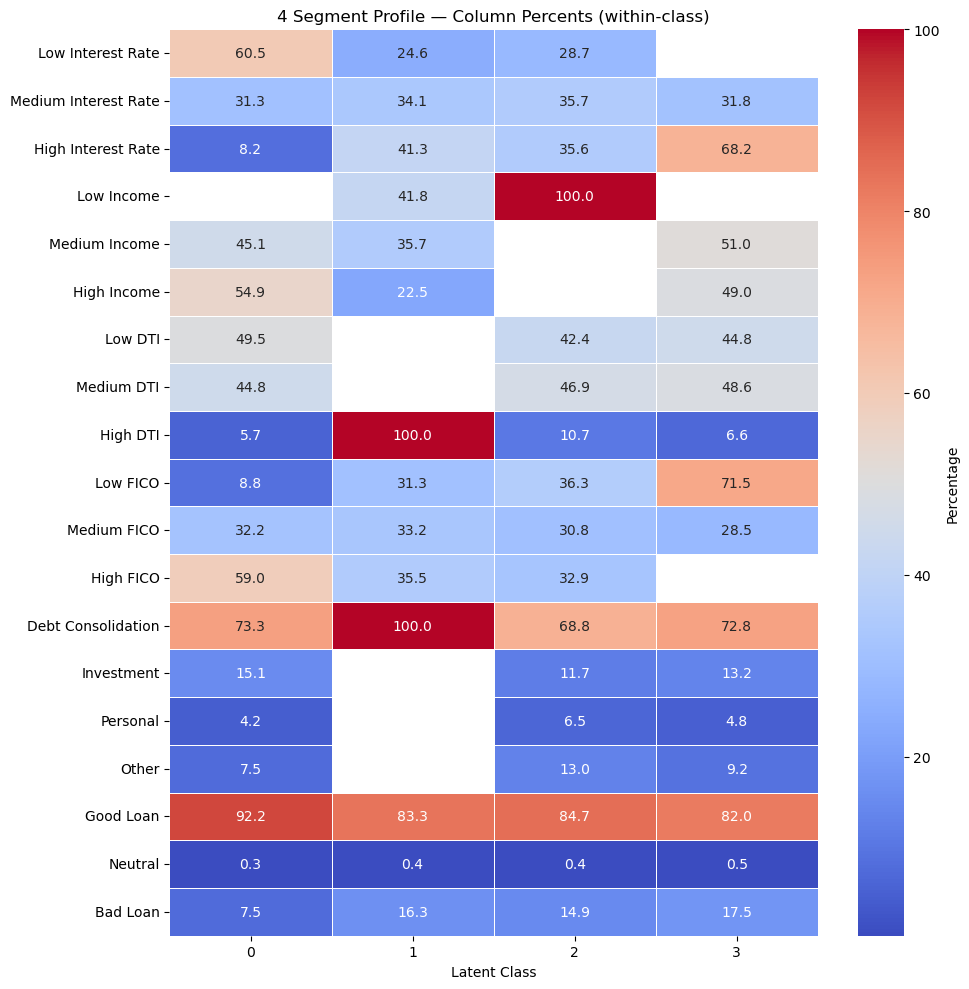

In [60]:
# Column-percent heatmap (within-class profile)
plt.figure(figsize=(10, 10))
sns.heatmap(col_percent_labeled, annot=True, fmt=".1f",
            cmap="coolwarm", linewidths=.5,
            cbar_kws={'label': 'Percentage'})
plt.title("4 Segment Profile — Column Percents (within-class)")
plt.xlabel("Latent Class")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/lca_heatmap.png", dpi=200, bbox_inches='tight')
plt.show()

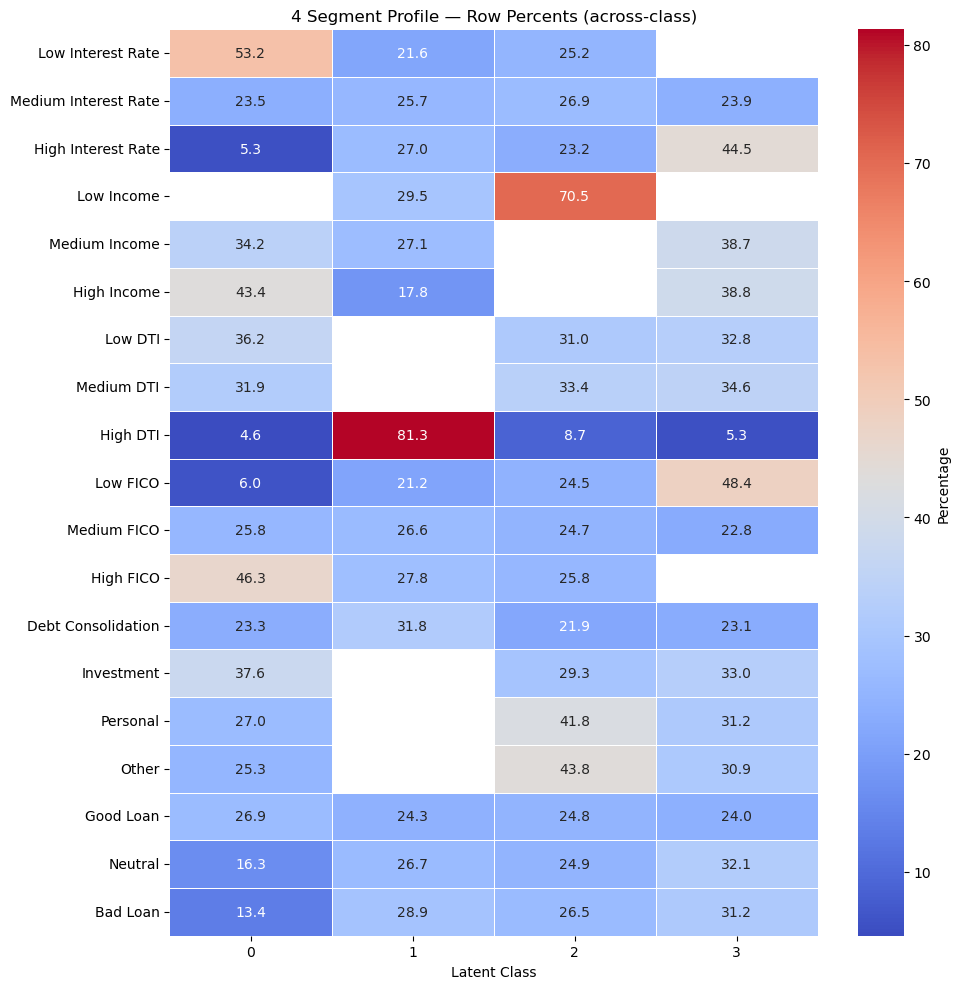

In [61]:
# Row-percent heatmap (across-class) — of everyone with attribute X, what % are in each class
row_percent = summary_df.T
row_percent = row_percent.div(row_percent.sum(axis=1), axis=0) * 100
row_percent = row_percent.round(1)
row_percent.to_csv(f"{OUTPUT_DIR}/latent_class_summary_4class_row_percents.csv")

row_percent_labeled = row_percent.copy()
row_percent_labeled.index = [label_map.get(lbl, lbl) for lbl in row_percent_labeled.index]
row_percent_labeled = row_percent_labeled.reindex(
    [r for r in row_order if r in row_percent_labeled.index])

plt.figure(figsize=(10, 10))
sns.heatmap(row_percent_labeled, annot=True, fmt=".1f",
            cmap="coolwarm", linewidths=.5,
            cbar_kws={'label': 'Percentage'})
plt.title("4 Segment Profile — Row Percents (across-class)")
plt.xlabel("Latent Class")
plt.tight_layout()
plt.show()

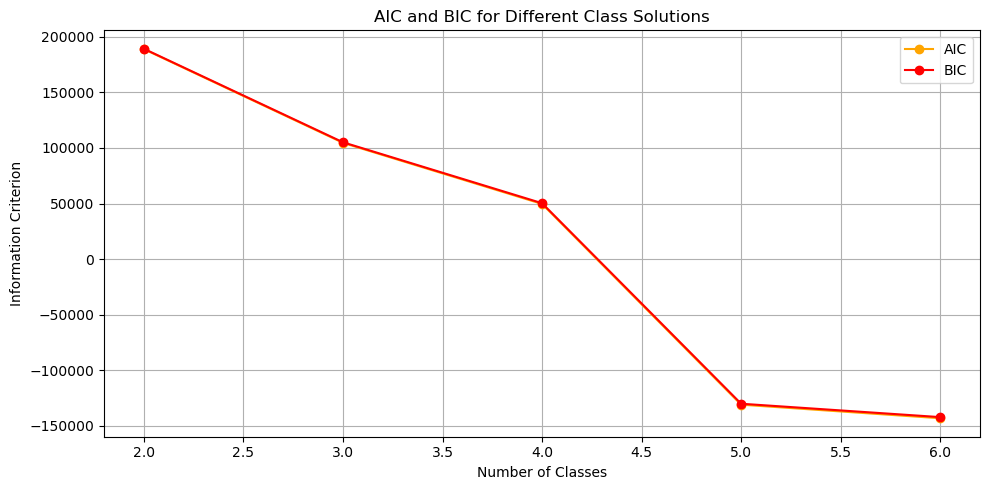

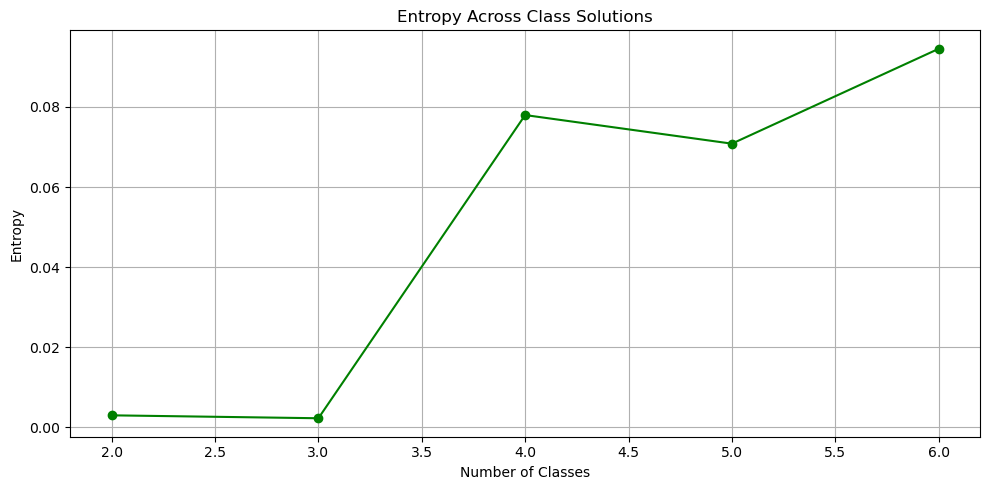

In [62]:
# Model selection: AIC, BIC, Entropy across 2-6 classes
metrics = []
for n_classes in range(2, 7):
    g = GaussianMixture(n_components=n_classes, random_state=42)
    g.fit(X)
    probs = g.predict_proba(X)
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1).mean()
    metrics.append({
        "Classes": n_classes,
        "AIC": g.aic(X),
        "BIC": g.bic(X),
        "Entropy": entropy
    })
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(f"{OUTPUT_DIR}/lca_model_metrics.csv", index=False)

plt.figure(figsize=(10, 5))
plt.plot(metrics_df["Classes"], metrics_df["AIC"], marker='o', label="AIC", color='orange')
plt.plot(metrics_df["Classes"], metrics_df["BIC"], marker='o', label="BIC", color='red')
plt.xlabel("Number of Classes")
plt.ylabel("Information Criterion")
plt.title("AIC and BIC for Different Class Solutions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(metrics_df["Classes"], metrics_df["Entropy"], marker='o', color='green')
plt.xlabel("Number of Classes")
plt.ylabel("Entropy")
plt.title("Entropy Across Class Solutions")
plt.grid(True)
plt.tight_layout()
plt.show()